Loading normalized WESAD dataset...
Running Late Fusion LOSO Validation on 15 subjects...


LOSO Iterations: 100%|██████████| 15/15 [00:02<00:00,  5.76it/s]


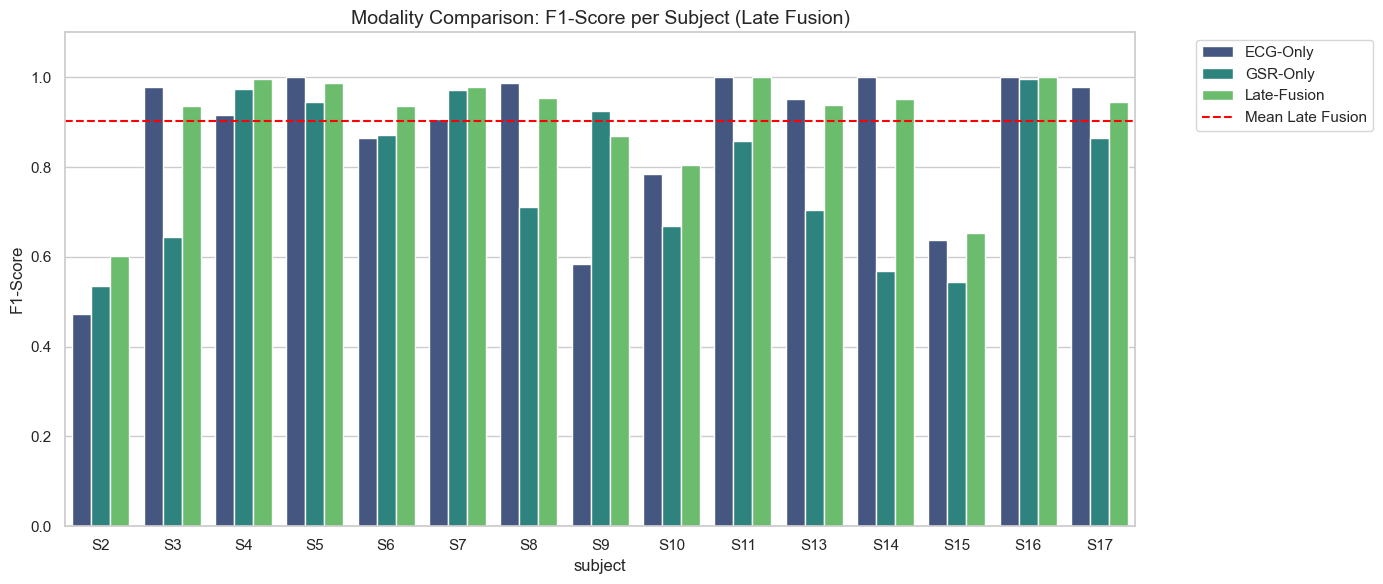

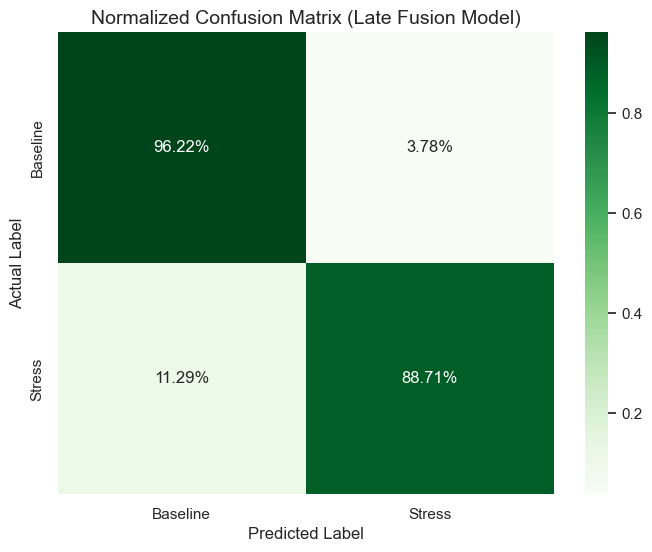


--- LATE FUSION PERFORMANCE SUMMARY ---
Mean ECG-Only F1   : 0.8708
Mean GSR-Only F1   : 0.7853
Mean Late-Fusion F1: 0.9034
Plots saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# --- DATA PREPARATION ---
print("Loading normalized WESAD dataset...")
df = pd.read_csv('wesad_final_normalized_features.csv')

ecg_cols = [c for c in df.columns if 'HRV' in c or 'ECG_Rate' in c]
gsr_cols = [c for c in df.columns if 'SCR' in c or 'EDA' in c]

df['label_idx'] = df['label'].map({1: 0, 2: 1})
df = df[df['label_idx'].notnull()] 

subjects = df['subject_id'].unique()
loso_results = []

all_actual = []
all_preds_late = []

print(f"Running Late Fusion LOSO Validation on {len(subjects)} subjects...")

# --- LOSO LOOP ---
for test_sub in tqdm(subjects, desc="LOSO Iterations"):
    train_df = df[df['subject_id'] != test_sub]
    test_df = df[df['subject_id'] == test_sub]
    
    y_train = train_df['label_idx']
    y_test = test_df['label_idx']
    
    sub_metrics = {'subject': test_sub}
    
    model_ecg = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
    model_gsr = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
    
    model_ecg.fit(train_df[ecg_cols], y_train)
    model_gsr.fit(train_df[gsr_cols], y_train)
    
    # Get Unimodal Predictions
    preds_ecg = model_ecg.predict(test_df[ecg_cols])
    preds_gsr = model_gsr.predict(test_df[gsr_cols])
    
    sub_metrics['ECG-Only_Acc'] = accuracy_score(y_test, preds_ecg)
    sub_metrics['ECG-Only_F1'] = f1_score(y_test, preds_ecg)
    sub_metrics['GSR-Only_Acc'] = accuracy_score(y_test, preds_gsr)
    sub_metrics['GSR-Only_F1'] = f1_score(y_test, preds_gsr)
    
    # --- LATE FUSION ---
    prob_ecg = model_ecg.predict_proba(test_df[ecg_cols])[:, 1]
    prob_gsr = model_gsr.predict_proba(test_df[gsr_cols])[:, 1]
    
    # Average the probabilities
    prob_fusion = (prob_ecg + prob_gsr) / 2.0
    preds_fusion = (prob_fusion >= 0.5).astype(int)
    
    sub_metrics['Late-Fusion_Acc'] = accuracy_score(y_test, preds_fusion)
    sub_metrics['Late-Fusion_F1'] = f1_score(y_test, preds_fusion)
    
    loso_results.append(sub_metrics)
    
    all_actual.extend(y_test.tolist())
    all_preds_late.extend(preds_fusion.tolist())

# --- RESULTS ---
results_df = pd.DataFrame(loso_results)
results_df.to_csv('loso_late_fusion_results.csv', index=False)

# --- VISUALIZATION ---
sns.set_theme(style="whitegrid")

# Plot A: Subject-wise F1 Comparison
plot_df = results_df.melt(id_vars='subject', 
                          value_vars=['ECG-Only_F1', 'GSR-Only_F1', 'Late-Fusion_F1'],
                          var_name='Modality', value_name='F1-Score')
plot_df['Modality'] = plot_df['Modality'].str.replace('_F1', '')

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='subject', y='F1-Score', hue='Modality', palette='viridis')
plt.axhline(results_df['Late-Fusion_F1'].mean(), color='red', linestyle='--', label='Mean Late Fusion')
plt.title('Modality Comparison: F1-Score per Subject (Late Fusion)', fontsize=14)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('thesis_late_fusion_bars.png', dpi=300)
plt.show()

# Plot B: Global Confusion Matrix for Late Fusion
cm_norm = confusion_matrix(all_actual, all_preds_late, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', 
            xticklabels=['Baseline', 'Stress'], 
            yticklabels=['Baseline', 'Stress'])
plt.title('Normalized Confusion Matrix (Late Fusion Model)', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('thesis_late_fusion_matrix.png', dpi=300)
plt.show()

print("\n--- LATE FUSION PERFORMANCE SUMMARY ---")
print(f"Mean ECG-Only F1   : {results_df['ECG-Only_F1'].mean():.4f}")
print(f"Mean GSR-Only F1   : {results_df['GSR-Only_F1'].mean():.4f}")
print(f"Mean Late-Fusion F1: {results_df['Late-Fusion_F1'].mean():.4f}")
print("Plots saved successfully.")

Loading data for Weighted Late Fusion...
Running Weighted LOSO Validation on 15 subjects...


Weighted LOSO Iterations: 100%|██████████| 15/15 [00:02<00:00,  6.12it/s]



--- WEIGHTED LATE FUSION SUMMARY (60% ECG / 40% GSR) ---
Mean ECG-Only F1      : 0.8708
Mean GSR-Only F1      : 0.7853
Overall Weighted F1   : 0.9028


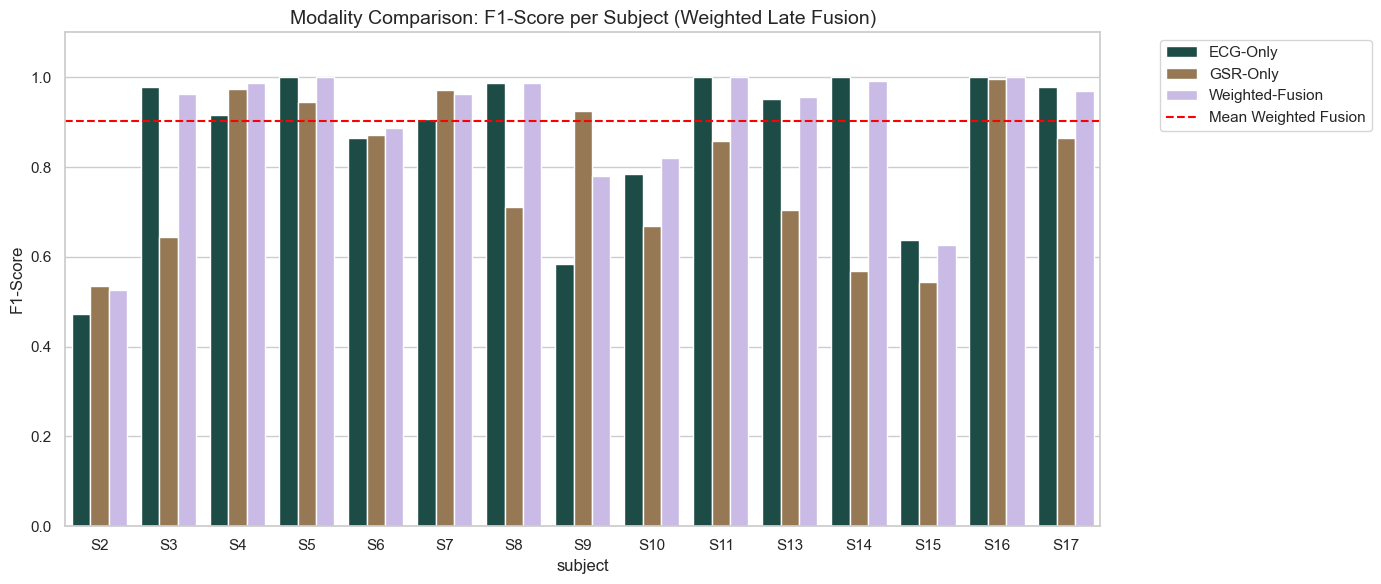

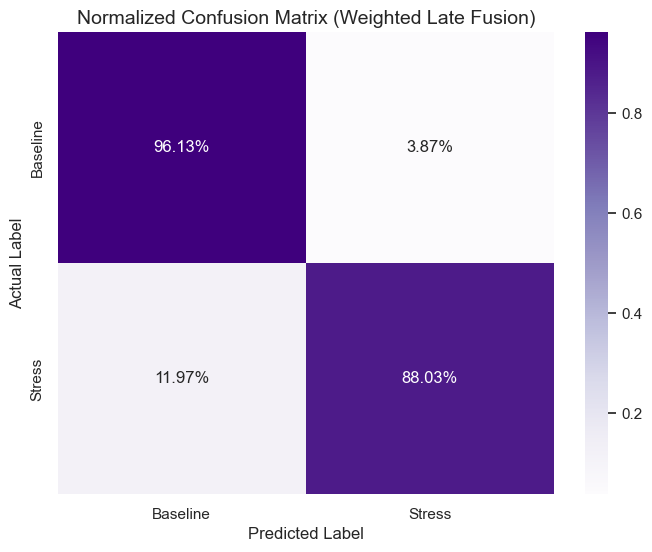

Weighted analysis complete. Plots saved as 'thesis_weighted_fusion_bars.png' and 'thesis_weighted_fusion_matrix.png'.


In [ ]:
# --- 1. DATA PREPARATION ---
print("Loading data for Weighted Late Fusion...")
df = pd.read_csv('wesad_final_normalized_features.csv')

ecg_cols = [c for c in df.columns if 'HRV' in c or 'ECG_Rate' in c]
gsr_cols = [c for c in df.columns if 'SCR' in c or 'EDA' in c]

df['label_idx'] = df['label'].map({1: 0, 2: 1})
df = df[df['label_idx'].notnull()] 

subjects = df['subject_id'].unique()
loso_results = []
all_actual = []
all_preds_weighted = []

print(f"Running Weighted LOSO Validation on {len(subjects)} subjects...")

# --- WEIGHTED LOSO ---
for test_sub in tqdm(subjects, desc="Weighted LOSO Iterations"):
    train_df = df[df['subject_id'] != test_sub]
    test_df = df[df['subject_id'] == test_sub]
    
    y_train = train_df['label_idx']
    y_test = test_df['label_idx']
    
    sub_metrics = {'subject': test_sub}
    
    model_ecg = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
    model_gsr = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
    
    model_ecg.fit(train_df[ecg_cols], y_train)
    model_gsr.fit(train_df[gsr_cols], y_train)
    
    # Unimodal metrics for comparison
    preds_ecg = model_ecg.predict(test_df[ecg_cols])
    preds_gsr = model_gsr.predict(test_df[gsr_cols])
    sub_metrics['ECG-Only_F1'] = f1_score(y_test, preds_ecg)
    sub_metrics['GSR-Only_F1'] = f1_score(y_test, preds_gsr)
    
    # --- WEIGHTED FUSION ---
    prob_ecg = model_ecg.predict_proba(test_df[ecg_cols])[:, 1]
    prob_gsr = model_gsr.predict_proba(test_df[gsr_cols])[:, 1]
    
    # Apply the 60/40 split
    weight_ecg = 0.60
    weight_gsr = 0.40
    prob_weighted = (weight_ecg * prob_ecg) + (weight_gsr * prob_gsr)
    
    # Final threshold decision
    preds_weighted = (prob_weighted >= 0.5).astype(int)
    
    sub_metrics['Weighted-Fusion_Acc'] = accuracy_score(y_test, preds_weighted)
    sub_metrics['Weighted-Fusion_F1'] = f1_score(y_test, preds_weighted)
    
    loso_results.append(sub_metrics)
    all_actual.extend(y_test.tolist())
    all_preds_weighted.extend(preds_weighted.tolist())

# --- RESULTS ---
results_df = pd.DataFrame(loso_results)
final_acc = accuracy_score(all_actual, all_preds_weighted)
final_f1 = f1_score(all_actual, all_preds_weighted)

print("\n--- WEIGHTED LATE FUSION SUMMARY (60% ECG / 40% GSR) ---")
print(f"Mean ECG-Only F1      : {results_df['ECG-Only_F1'].mean():.4f}")
print(f"Mean GSR-Only F1      : {results_df['GSR-Only_F1'].mean():.4f}")
print(f"Overall Weighted F1   : {final_f1:.4f}")

# --- VISUALIZATION ---
sns.set_theme(style="whitegrid")

# Plot A: Subject-wise F1 Comparison
plot_df = results_df.melt(id_vars='subject', 
                          value_vars=['ECG-Only_F1', 'GSR-Only_F1', 'Weighted-Fusion_F1'],
                          var_name='Modality', value_name='F1-Score')
plot_df['Modality'] = plot_df['Modality'].str.replace('_F1', '')

plt.figure(figsize=(14, 6))
# Using a different color palette to visually separate it from the 50/50 Late Fusion
sns.barplot(data=plot_df, x='subject', y='F1-Score', hue='Modality', palette='cubehelix')
plt.axhline(final_f1, color='red', linestyle='--', label='Mean Weighted Fusion')
plt.title('Modality Comparison: F1-Score per Subject (Weighted Late Fusion)', fontsize=14)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('thesis_weighted_fusion_bars.png', dpi=300)
plt.show()

# Plot B: Global Confusion Matrix for Weighted Late Fusion
cm_norm = confusion_matrix(all_actual, all_preds_weighted, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples', 
            xticklabels=['Baseline', 'Stress'], 
            yticklabels=['Baseline', 'Stress'])
plt.title('Normalized Confusion Matrix (Weighted Late Fusion)', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('thesis_weighted_fusion_matrix.png', dpi=300)
plt.show()

print("Weighted analysis complete. Plots saved as 'thesis_weighted_fusion_bars.png' and 'thesis_weighted_fusion_matrix.png'.")